# Do NHL Forwards Score More Points Per Game Than Defensemen?

## Research Question

Do NHL forwards have a higher average points per game (PPG) than defensemen during the 2025–26 regular season?

### Hypotheses

- **H₀ (null hypothesis):** Forwards do not have a higher mean PPG than defensemen.
- **H₁ (alternative hypothesis):** Forwards have a higher mean PPG than defensemen.

## Data

This analysis uses NHL skater statistics for the 2025–2026 regular season.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_csv("../data/skaters_by_season_summary.csv")

df.head()

,assists,evGoals,evPoints,faceoffWinPct,gameWinningGoals,gamesPlayed,goals,lastName,otGoals,penaltyMinutes,...,ppPoints,seasonId,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrevs,timeOnIcePerGame
0,10,NaN,NaN,NaN,2,21,36,Denneny,0,80,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Cy Denneny,SEN,NaN
1,10,NaN,NaN,NaN,1,21,17,Cameron,0,28,...,NaN,19171918,NaN,NaN,NaN,R,NaN,Harry Cameron,TAN,NaN
2,3,NaN,NaN,NaN,1,18,3,Mummery,0,41,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Harry Mummery,TAN,NaN
3,9,NaN,NaN,NaN,1,21,11,Meeking,0,28,...,NaN,19171918,NaN,NaN,NaN,L,NaN,Harry Meeking,TAN,NaN
4,1,NaN,NaN,NaN,0,18,2,Laviolette,0,6,...,NaN,19171918,NaN,NaN,NaN,R,NaN,Jack Laviolette,MTL,NaN


In [27]:
print(df.columns)
print(df["seasonId"].unique())

Index(['assists', 'evGoals', 'evPoints', 'faceoffWinPct', 'gameWinningGoals',
       'gamesPlayed', 'goals', 'lastName', 'otGoals', 'penaltyMinutes',
       'playerId', 'plusMinus', 'points', 'pointsPerGame', 'positionCode',
       'ppGoals', 'ppPoints', 'seasonId', 'shGoals', 'shPoints', 'shootingPct',
       'shootsCatches', 'shots', 'skaterFullName', 'teamAbbrevs',
       'timeOnIcePerGame'],
      dtype='str')
[19171918 19181919 19191920 19201921 19211922 19221923 19231924 19241925
 19251926 19261927 19271928 19281929 19291930 19301931 19311932 19321933
 19331934 19341935 19351936 19361937 19371938 19381939 19391940 19401941
 19411942 19421943 19431944 19441945 19451946 19461947 19471948 19481949
 19491950 19501951 19511952 19521953 19531954 19541955 19551956 19561957
 19571958 19581959 19591960 19601961 19611962 19621963 19631964 19641965
 19651966 19661967 19671968 19681969 19691970 19701971 19711972 19721973
 19731974 19741975 19751976 19761977 19771978 19781979 19791980 1980198

In [28]:
# create a new DataFrame containing only the 2025-2026 season
df_2526 = df[df["seasonId"] == 20252026].copy()
df_2526.shape

(940, 26)

In [29]:
# show the counts of each position code in the 2025-2026 season
df_2526["positionCode"].value_counts()


positionCode
D    319
C    300
L    167
R    154
Name: count, dtype: int64

For our analysis, we will group C, L, and R as forwards, and D as defensemen.

In [30]:
df_2526["positionGroup"] = df_2526["positionCode"].map({
    "C": "Forward",
    "L": "Forward",
    "R": "Forward",
    "D": "Defenseman"
})
df_2526["positionGroup"].value_counts()

positionGroup
Forward       621
Defenseman    319
Name: count, dtype: int64

In [31]:
# Check for missing values in the "pointsPerGame" column
df_2526["pointsPerGame"].isna().sum()

np.int64(0)

In [32]:
print(f"{df_2526['pointsPerGame'].describe()}\n\n{df_2526['gamesPlayed'].describe()}")

count    940.000000
mean       0.377961
std        0.305604
min        0.000000
25%        0.166660
50%        0.294225
75%        0.514385
max        2.000000
Name: pointsPerGame, dtype: float64

count    940.000000
mean      50.242553
std       29.067413
min        1.000000
25%       22.750000
50%       61.000000
75%       77.000000
max       83.000000
Name: gamesPlayed, dtype: float64


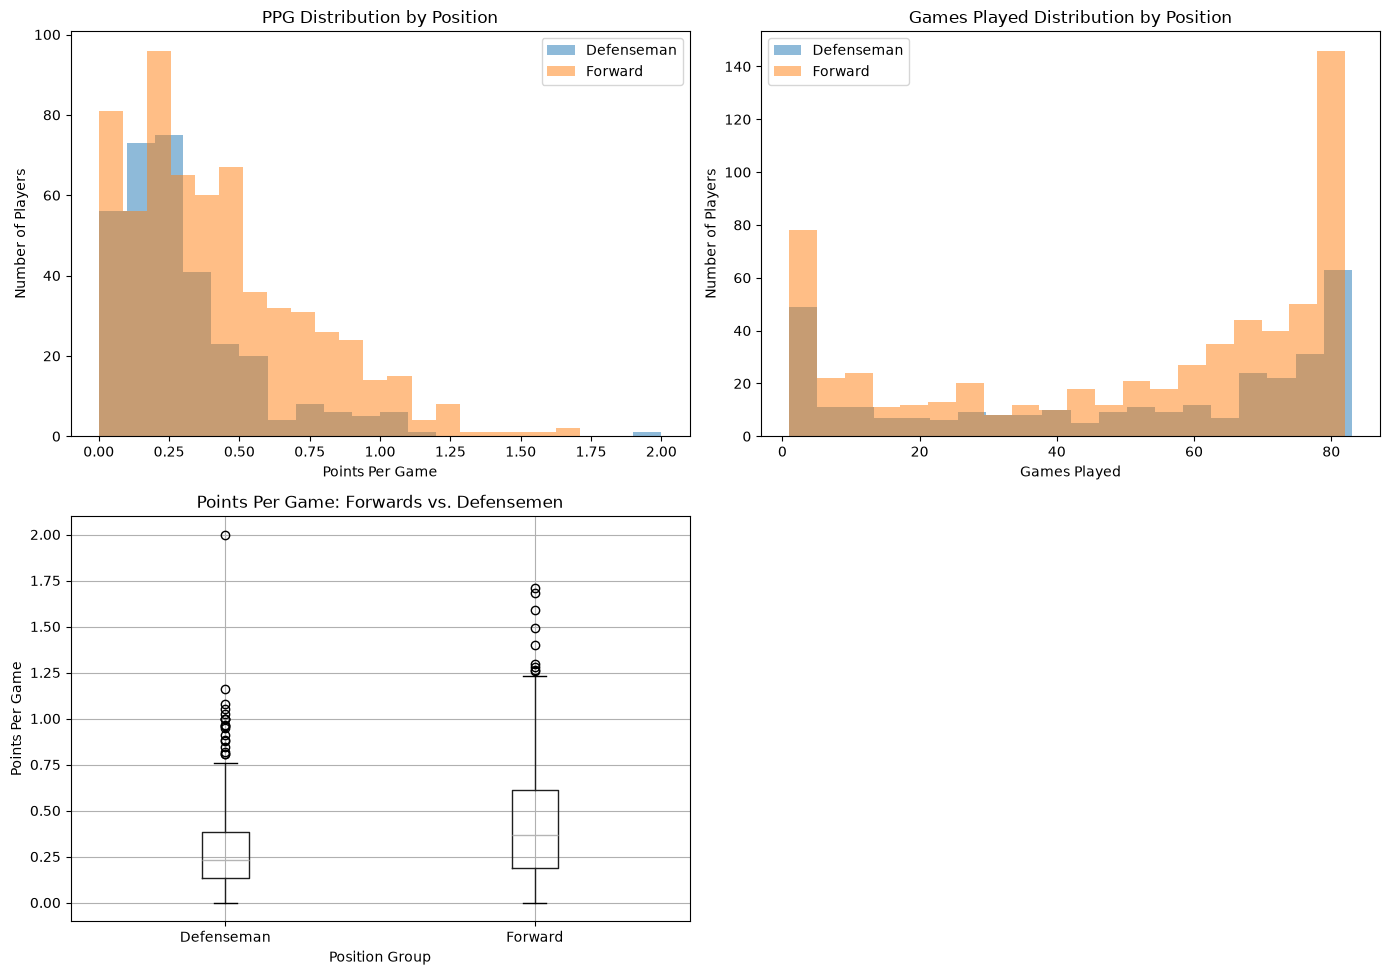

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # turns 2x2 grid into a flat list: axes[0..3]

df_2526.groupby("positionGroup")["pointsPerGame"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[0]
)
axes[0].set_xlabel("Points Per Game")
axes[0].set_ylabel("Number of Players")
axes[0].set_title("PPG Distribution by Position")

df_2526.groupby("positionGroup")["gamesPlayed"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[1]
)
axes[1].set_xlabel("Games Played")
axes[1].set_ylabel("Number of Players")
axes[1].set_title("Games Played Distribution by Position")

df_2526.boxplot(
    column="pointsPerGame",
    by="positionGroup",
    ax=axes[2]
)
axes[2].set_title("Points Per Game: Forwards vs. Defensemen")
axes[2].set_xlabel("Position Group")
axes[2].set_ylabel("Points Per Game")

axes[3].axis("off")  # hide the unused 4th subplot

plt.suptitle("")  # removes pandas' auto-added "Boxplot grouped by..." title
plt.tight_layout()
plt.show()

In [34]:
df_2526["gamesPlayed"].value_counts().sort_index().head(20)

gamesPlayed
1     32
2     22
3     34
4     24
5     15
6     10
7      5
8      7
9     11
10     6
11    10
12     8
13    11
14     5
15     6
16     3
17     4
18     5
19     6
20     4
Name: count, dtype: int64

In [35]:
df_2526.groupby("positionGroup")["pointsPerGame"].mean()

positionGroup
Defenseman    0.291921
Forward       0.422158
Name: pointsPerGame, dtype: float64

Descriptive analysis shows that forwards have a higher average PPG (0.422 vs. 0.292).

In [36]:
forwards = df_2526.loc[
    df_2526["positionGroup"] == "Forward",
    "pointsPerGame"
]

defensemen = df_2526.loc[
    df_2526["positionGroup"] == "Defenseman",
    "pointsPerGame"
]

test_result = ttest_ind(
    forwards,
    defensemen,
    equal_var=False,
    alternative="greater"
)

test_result

TtestResult(statistic=np.float64(6.78525792861537), pvalue=np.float64(1.146685126745954e-11), df=np.float64(779.4441579017873))